<a href="https://colab.research.google.com/github/J-R4M/machine-learning/blob/main/hw-2/Homework_2_4105.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 2

## Setup

### Import Libraries


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Learning Rates and Iterations

In [ ]:
learning_rates = [0.01, 0.03, 0.05, 0.07, 0.10]
iterations = 1000

### Load Housing Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Housing.csv')

print("# of samples: ", len(data))
print("Columns: ", list(data.columns))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
# of samples:  545
Columns:  ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


### Cost Function

In [ ]:
def compute_cost(X, Y, theta):
    predictions = X @ theta
    errors = predictions - Y

    if not np.all(np.isfinite(errors)):
        return np.inf

    with np.errstate(over='ignore', invalid='ignore'):
        cost = np.sum(errors ** 2) / (2 * len(Y))

    if not np.isfinite(cost):
        return np.inf

    return cost

### Gradient Descent Function

In [ ]:
def gradient_descent(
    X_train,
    Y_train,
    X_test,
    Y_test,
    learning_rate,
    iterations,
    lambda_reg=0
):
    m = len(Y_train)
    theta = np.zeros(X_train.shape[1])

    train_cost_history = []
    test_cost_history = []

    for i in range(iterations):
        predictions = X_train @ theta
        errors = predictions - Y_train

        regularization = theta.copy()
        regularization[0] = 0

        gradient = (
            (X_train.T @ errors) / m
            + (lambda_reg / m) * regularization
        )

        theta -= learning_rate * gradient

        train_cost = (
            compute_cost(X_train, Y_train, theta)
            + (lambda_reg / (2 * m))
            * np.sum(theta[1:] ** 2)
        )

        test_cost = compute_cost(
            X_test,
            Y_test,
            theta
        )

        train_cost_history.append(train_cost)
        test_cost_history.append(test_cost)

        if not np.isfinite(train_cost):
            print(f"Diverged at iteration {i + 1}")
            break

    return theta, train_cost_history, test_cost_history

### Results Table Function

In [ ]:
def create_results_table(results, learning_rates):
    comparison = []

    for lr in learning_rates:
        train_history = results[lr]['train_cost']
        test_history = results[lr]['test_cost']

        comparison.append([
            lr,
            len(train_history),
            train_history[-1],
            test_history[-1]
        ])

    return pd.DataFrame(
        comparison,
        columns=[
            'Learning Rate',
            'Iterations Completed',
            'Final Training Cost',
            'Final Validation Cost'
        ]
    )

### Plot Loss Function

In [ ]:
def plot_loss(results, learning_rate, title):
    train_history = results[learning_rate]['train_cost']
    test_history = results[learning_rate]['test_cost']

    iteration_range = range(
        1,
        len(train_history) + 1
    )

    plt.figure(figsize=(8, 5))

    plt.plot(
        iteration_range,
        train_history,
        label='Training Loss'
    )

    plt.plot(
        iteration_range,
        test_history,
        label='Validation Loss'
    )

    plt.xlabel('Iteration')
    plt.ylabel('Cost')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.show()

### Standardization Function

In [ ]:
def standardize_inputs(X_train, X_test):
    mean = np.mean(X_train, axis=0)
    std = np.std(X_train, axis=0)

    std = np.where(std == 0, 1, std)

    X_train_standardized = (X_train - mean) / std
    X_test_standardized = (X_test - mean) / std

    return X_train_standardized, X_test_standardized

### Normalization Function

In [ ]:
def normalize_inputs(X_train, X_test):
    minimum = np.min(X_train, axis=0)
    maximum = np.max(X_train, axis=0)

    feature_range = maximum - minimum

    # Prevent division by zero for constant features
    feature_range = np.where(feature_range == 0, 1, feature_range)

    X_train_normalized = (
        (X_train - minimum) / feature_range
    )

    X_test_normalized = (
        (X_test - minimum) / feature_range
    )

    return X_train_normalized, X_test_normalized

## Problem 1a

### Select Input/Output Variables

In [ ]:
features = [
    'area',
    'bedrooms',
    'bathrooms',
    'stories',
    'parking'
]

X = data[features].to_numpy(dtype=float)
Y = data['price'].to_numpy(dtype=float)

print("Input matrix shape:", X.shape)
print("Output vector shape:", Y.shape)


Input matrix shape: (545, 5)
Output vector shape: (545,)


### 80/20 Training/Test Split

In [ ]:
np.random.seed(8675309)

indices = np.random.permutation(len(X))

split_index = int(len(X) * 0.8)

train_indices = indices[:split_index]
test_indices = indices[split_index:]

X_train = X[train_indices]
Y_train = Y[train_indices]

X_test = X[test_indices]
Y_test = Y[test_indices]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 436
Testing samples: 109


### Add Bias Term

In [ ]:
X_train_bias = np.column_stack((
    np.ones(len(X_train)),
    X_train
))

X_test_bias = np.column_stack((
    np.ones(len(X_test)),
    X_test
))

print("Training matrix shape:", X_train_bias.shape)
print("Testing matrix shape:", X_test_bias.shape)

Training matrix shape: (436, 6)
Testing matrix shape: (109, 6)


### Learning Rate Evaluation

In [ ]:
results = {}

for lr in learning_rates:
    theta, train_cost_history, test_cost_history = gradient_descent(
        X_train_bias,
        Y_train,
        X_test_bias,
        Y_test,
        lr,
        iterations
    )

    results[lr] = {
        'theta': theta,
        'train_cost': train_cost_history,
        'test_cost': test_cost_history
    }

Diverged at iteration 27
Diverged at iteration 25
Diverged at iteration 24
Diverged at iteration 24
Diverged at iteration 23


/tmp/ipykernel_12391/481086225.py:33: RuntimeWarning: overflow encountered in square
  * np.sum(theta[1:] ** 2)
/tmp/ipykernel_12391/481086225.py:32: RuntimeWarning: invalid value encountered in scalar multiply
  + (lambda_reg / (2 * m))


### Learning Rate Results


In [ ]:
comparison_df = create_results_table(
    results,
    learning_rates
)

comparison_df

,Learning Rate,Iterations Completed,Final Training Cost,Final Validation Cost
0,0.01,27,inf,inf
1,0.03,25,inf,inf
2,0.05,24,inf,inf
3,0.07,24,NaN,inf
4,0.10,23,inf,inf


### Training and Validation Loss

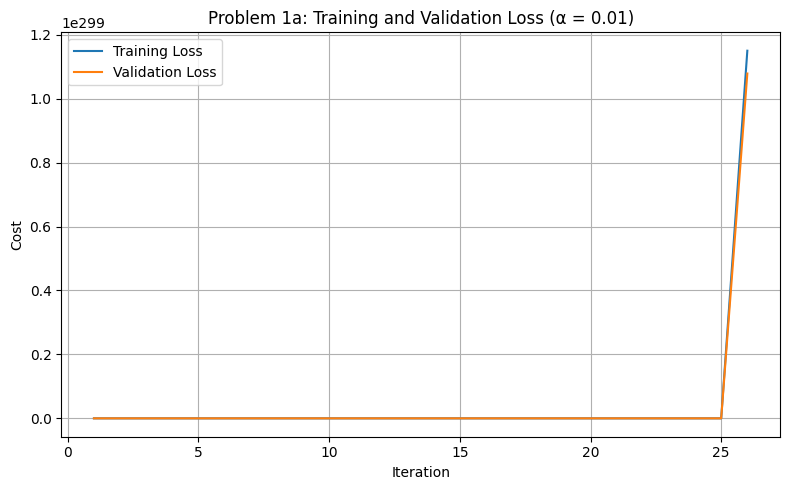

In [ ]:
plot_loss(
    results,
    0.01,
    'Problem 1a: Training and Validation Loss (α = 0.01)'
)

### Results and Discussion

The model was trained using the raw input variables: area, bedrooms, bathrooms, stories, and parking. The parameters were initialized to zero, and learning rates of 0.01, 0.03, 0.05, 0.07, and 0.10 were used. All rates diverged before completing 1000 iterations, but 0.01 remained stable the longest.

## Problem 1b

### Encode Binary Input Variables

In [ ]:
data_1b = data.copy()

binary_features = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for feature in binary_features:
    data_1b[feature] = data_1b[feature].map({
        'yes': 1,
        'no': 0
    })

### Select Input/Output Variables

In [ ]:
features_1b = [
    'area',
    'bedrooms',
    'bathrooms',
    'stories',
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'parking',
    'prefarea'
]

X_1b = data_1b[features_1b].to_numpy(dtype=float)
Y_1b = data_1b['price'].to_numpy(dtype=float)

print("Input matrix shape:", X_1b.shape)
print("Output vector shape:", Y_1b.shape)

Input matrix shape: (545, 11)
Output vector shape: (545,)


### 80/20 Training/Test Split

In [ ]:
X_train_1b = X_1b[train_indices]
Y_train_1b = Y_1b[train_indices]

X_test_1b = X_1b[test_indices]
Y_test_1b = Y_1b[test_indices]

print("Training samples:", len(X_train_1b))
print("Testing samples:", len(X_test_1b))

Training samples: 436
Testing samples: 109


### Add Bias Term



In [ ]:
X_train_bias_1b = np.column_stack((
    np.ones(len(X_train_1b)),
    X_train_1b
))

X_test_bias_1b = np.column_stack((
    np.ones(len(X_test_1b)),
    X_test_1b
))

print("Training matrix shape:", X_train_bias_1b.shape)
print("Testing matrix shape:", X_test_bias_1b.shape)

Training matrix shape: (436, 12)
Testing matrix shape: (109, 12)


### Learning Rate Evaluation

In [ ]:
results_1b = {}

for lr in learning_rates:
    theta, train_cost_history, test_cost_history = gradient_descent(
        X_train_bias_1b,
        Y_train_1b,
        X_test_bias_1b,
        Y_test_1b,
        lr,
        iterations
    )

    results_1b[lr] = {
        'theta': theta,
        'train_cost': train_cost_history,
        'test_cost': test_cost_history
    }

Diverged at iteration 27
Diverged at iteration 25
Diverged at iteration 24
Diverged at iteration 24
Diverged at iteration 23


/tmp/ipykernel_12391/481086225.py:33: RuntimeWarning: overflow encountered in square
  * np.sum(theta[1:] ** 2)
/tmp/ipykernel_12391/481086225.py:32: RuntimeWarning: invalid value encountered in scalar multiply
  + (lambda_reg / (2 * m))


### Learning Rate Results

In [ ]:
comparison_1b_df = create_results_table(
    results_1b,
    learning_rates
)

comparison_1b_df

,Learning Rate,Iterations Completed,Final Training Cost,Final Validation Cost
0,0.01,27,inf,inf
1,0.03,25,inf,inf
2,0.05,24,inf,inf
3,0.07,24,NaN,inf
4,0.10,23,inf,inf


### Training and Validation Loss

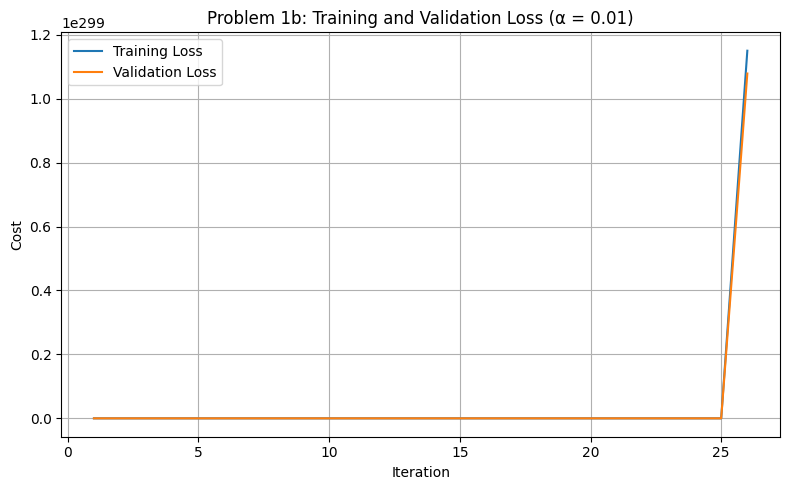

In [ ]:
plot_loss(
    results_1b,
    0.01,
    'Problem 1b: Training and Validation Loss (α = 0.01)'
)

### Comparison with Problem 1a

Problem 1a used 5 variables, while 1b used 11 while also including binary housing characteristics.

Both models showed the same convergence behavior for the same tested learning rates, meaning a valid parameter set could not be found yet using the required α range provided.

## Problem 2a

### Standardize and Normalize Input Data

In [ ]:
X_train_standardized, X_test_standardized = standardize_inputs(
    X_train,
    X_test
)

X_train_normalized, X_test_normalized = normalize_inputs(
    X_train,
    X_test
)

print("Standardized training shape:", X_train_standardized.shape)
print("Standardized testing shape:", X_test_standardized.shape)

print("Normalized training shape:", X_train_normalized.shape)
print("Normalized testing shape:", X_test_normalized.shape)

Standardized training shape: (436, 5)
Standardized testing shape: (109, 5)
Normalized training shape: (436, 5)
Normalized testing shape: (109, 5)


### Add Bias Terms

In [ ]:
X_train_standardized_bias = np.column_stack((
    np.ones(len(X_train_standardized)),
    X_train_standardized
))

X_test_standardized_bias = np.column_stack((
    np.ones(len(X_test_standardized)),
    X_test_standardized
))

X_train_normalized_bias = np.column_stack((
    np.ones(len(X_train_normalized)),
    X_train_normalized
))

X_test_normalized_bias = np.column_stack((
    np.ones(len(X_test_normalized)),
    X_test_normalized
))

print(
    "Standardized training matrix:",
    X_train_standardized_bias.shape
)

print(
    "Normalized training matrix:",
    X_train_normalized_bias.shape
)

Standardized training matrix: (436, 6)
Normalized training matrix: (436, 6)


### Train Standardized Model

In [ ]:
results_standardized = {}

for lr in learning_rates:
    theta, train_cost_history, test_cost_history = gradient_descent(
        X_train_standardized_bias,
        Y_train,
        X_test_standardized_bias,
        Y_test,
        lr,
        iterations
    )

    results_standardized[lr] = {
        'theta': theta,
        'train_cost': train_cost_history,
        'test_cost': test_cost_history
    }

### Standardized Learning Rate Results

In [ ]:
comparison_standardized_df = create_results_table(
    results_standardized,
    learning_rates
)

comparison_standardized_df

,Learning Rate,Iterations Completed,Final Training Cost,Final Validation Cost
0,0.01,1000,8.111547e+11,5.841122e+11
1,0.03,1000,8.111544e+11,5.841181e+11
2,0.05,1000,8.111544e+11,5.841181e+11
3,0.07,1000,8.111544e+11,5.841181e+11
4,0.10,1000,8.111544e+11,5.841181e+11


### Train Normalized Model

In [ ]:
results_normalized = {}

for lr in learning_rates:
    theta, train_cost_history, test_cost_history = gradient_descent(
        X_train_normalized_bias,
        Y_train,
        X_test_normalized_bias,
        Y_test,
        lr,
        iterations
    )

    results_normalized[lr] = {
        'theta': theta,
        'train_cost': train_cost_history,
        'test_cost': test_cost_history
    }

### Normalized Learning Rate Results

In [ ]:
comparison_normalized_df = create_results_table(
    results_normalized,
    learning_rates
)

comparison_normalized_df

,Learning Rate,Iterations Completed,Final Training Cost,Final Validation Cost
0,0.01,1000,1.009627e+12,7.045226e+11
1,0.03,1000,8.790676e+11,6.117201e+11
2,0.05,1000,8.388307e+11,5.914899e+11
3,0.07,1000,8.228712e+11,5.851138e+11
4,0.10,1000,8.145098e+11,5.829969e+11


### Pick Best Learning Rates

In [ ]:
standardized_candidates = comparison_standardized_df[
    (comparison_standardized_df['Iterations Completed'] == iterations)
    & np.isfinite(
        comparison_standardized_df['Final Training Cost']
    )
    & np.isfinite(
        comparison_standardized_df['Final Validation Cost']
    )
]

normalized_candidates = comparison_normalized_df[
    (comparison_normalized_df['Iterations Completed'] == iterations)
    & np.isfinite(
        comparison_normalized_df['Final Training Cost']
    )
    & np.isfinite(
        comparison_normalized_df['Final Validation Cost']
    )
]

if standardized_candidates.empty:
    raise ValueError(
        "No standardized learning rate completed training."
    )

if normalized_candidates.empty:
    raise ValueError(
        "No normalized learning rate completed training."
    )

best_lr_standardized = float(
    standardized_candidates.loc[
        standardized_candidates[
            'Final Validation Cost'
        ].idxmin(),
        'Learning Rate'
    ]
)

best_lr_normalized = float(
    normalized_candidates.loc[
        normalized_candidates[
            'Final Validation Cost'
        ].idxmin(),
        'Learning Rate'
    ]
)

print(
    "Best standardized learning rate:",
    best_lr_standardized
)

print(
    "Best normalized learning rate:",
    best_lr_normalized
)

Best standardized learning rate: 0.01
Best normalized learning rate: 0.1


### Best Model Parameters

In [ ]:
parameter_names = [
    'Intercept',
    'area',
    'bedrooms',
    'bathrooms',
    'stories',
    'parking'
]

theta_standardized = results_standardized[
    best_lr_standardized
]['theta']

theta_normalized = results_normalized[
    best_lr_normalized
]['theta']

parameters_2a_df = pd.DataFrame({
    'Parameter': parameter_names,
    'Standardized Theta': theta_standardized,
    'Normalized Theta': theta_normalized
})

parameters_2a_df

,Parameter,Standardized Theta,Normalized Theta
0,Intercept,4.794390e+06,2.290634e+06
1,area,7.435652e+05,4.356673e+06
2,bedrooms,1.303964e+05,1.109083e+06
3,bathrooms,5.816277e+05,3.206852e+06
4,stories,4.623087e+05,1.650689e+06
5,parking,3.380747e+05,1.278692e+06


### Standardized Training and Validation Loss

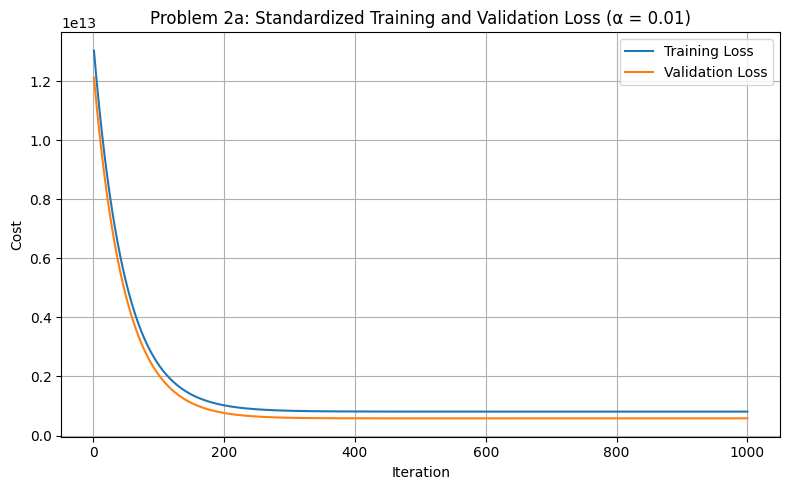

In [ ]:
plot_loss(
    results_standardized,
    best_lr_standardized,
    (
        'Problem 2a: Standardized Training and Validation Loss '
        f'(α = {best_lr_standardized})'
    )
)

### Normalized Training and Validation Loss

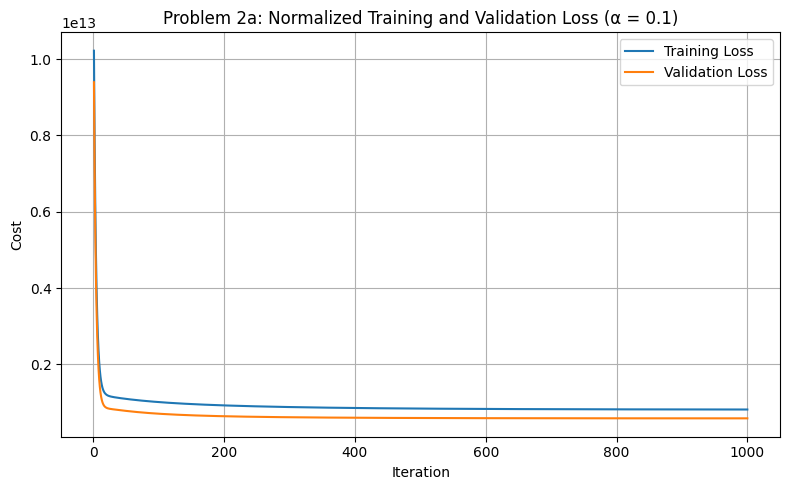

In [ ]:
plot_loss(
    results_normalized,
    best_lr_normalized,
    (
        'Problem 2a: Normalized Training and Validation Loss '
        f'(α = {best_lr_normalized})'
    )
)

### Comparison with Problem 1a

In [ ]:
baseline_lr = 0.01

comparison_2a_df = pd.DataFrame([
    {
        'Model': 'Problem 1a - Unscaled',
        'Learning Rate': baseline_lr,
        'Iterations Completed':
            len(results[baseline_lr]['train_cost']),
        'Final Training Cost':
            results[baseline_lr]['train_cost'][-1],
        'Final Validation Cost':
            results[baseline_lr]['test_cost'][-1]
    },
    {
        'Model': 'Problem 2a - Standardized',
        'Learning Rate': best_lr_standardized,
        'Iterations Completed':
            len(
                results_standardized[
                    best_lr_standardized
                ]['train_cost']
            ),
        'Final Training Cost':
            results_standardized[
                best_lr_standardized
            ]['train_cost'][-1],
        'Final Validation Cost':
            results_standardized[
                best_lr_standardized
            ]['test_cost'][-1]
    },
    {
        'Model': 'Problem 2a - Normalized',
        'Learning Rate': best_lr_normalized,
        'Iterations Completed':
            len(
                results_normalized[
                    best_lr_normalized
                ]['train_cost']
            ),
        'Final Training Cost':
            results_normalized[
                best_lr_normalized
            ]['train_cost'][-1],
        'Final Validation Cost':
            results_normalized[
                best_lr_normalized
            ]['test_cost'][-1]
    }
])

comparison_2a_df

,Model,Learning Rate,Iterations Completed,Final Training Cost,Final Validation Cost
0,Problem 1a - Unscaled,0.01,27,inf,inf
1,Problem 2a - Standardized,0.01,1000,8.111547e+11,5.841122e+11
2,Problem 2a - Normalized,0.10,1000,8.145098e+11,5.829969e+11


### Best Scaling Approach

In [ ]:
standardized_train_loss = results_standardized[
    best_lr_standardized
]['train_cost'][-1]

standardized_validation_loss = results_standardized[
    best_lr_standardized
]['test_cost'][-1]

normalized_train_loss = results_normalized[
    best_lr_normalized
]['train_cost'][-1]

normalized_validation_loss = results_normalized[
    best_lr_normalized
]['test_cost'][-1]

if standardized_train_loss < normalized_train_loss:
    best_training_scaling = 'Standardization'
else:
    best_training_scaling = 'Normalization'

if standardized_validation_loss < normalized_validation_loss:
    best_validation_scaling = 'Standardization'
else:
    best_validation_scaling = 'Normalization'

print(
    "Lowest final training loss:",
    best_training_scaling
)

print(
    "Lowest final validation loss:",
    best_validation_scaling
)

Lowest final training loss: Standardization
Lowest final validation loss: Normalization


### Results and Discussion

Problem 2a repeated the linear regression model from problem 1a using standardization and normalization as two separate pre-processing input methods. Everything about the comparison remained the same.

The standardized and normalized models were compared using their final training and validation losses. The scaling approach reported above with the lowest final training loss achieved the best training performance. The results demonstrate the effect that input scaling has on the stability of the gradient descent.

## Problem 2b

### Standardize and Normalize Input Data

In [ ]:
X_train_1b_standardized, X_test_1b_standardized = standardize_inputs(
    X_train_1b,
    X_test_1b
)

X_train_1b_normalized, X_test_1b_normalized = normalize_inputs(
    X_train_1b,
    X_test_1b
)

print(
    "Standardized training shape:",
    X_train_1b_standardized.shape
)

print(
    "Standardized testing shape:",
    X_test_1b_standardized.shape
)

print(
    "Normalized training shape:",
    X_train_1b_normalized.shape
)

print(
    "Normalized testing shape:",
    X_test_1b_normalized.shape
)

Standardized training shape: (436, 11)
Standardized testing shape: (109, 11)
Normalized training shape: (436, 11)
Normalized testing shape: (109, 11)


### Add Bias Terms


In [ ]:
X_train_1b_standardized_bias = np.column_stack((
    np.ones(len(X_train_1b_standardized)),
    X_train_1b_standardized
))

X_test_1b_standardized_bias = np.column_stack((
    np.ones(len(X_test_1b_standardized)),
    X_test_1b_standardized
))

X_train_1b_normalized_bias = np.column_stack((
    np.ones(len(X_train_1b_normalized)),
    X_train_1b_normalized
))

X_test_1b_normalized_bias = np.column_stack((
    np.ones(len(X_test_1b_normalized)),
    X_test_1b_normalized
))

print(
    "Standardized training matrix:",
    X_train_1b_standardized_bias.shape
)

print(
    "Normalized training matrix:",
    X_train_1b_normalized_bias.shape
)

Standardized training matrix: (436, 12)
Normalized training matrix: (436, 12)


### Standardization Training


In [ ]:
results_1b_standardized = {}

for lr in learning_rates:
    theta, train_cost_history, test_cost_history = gradient_descent(
        X_train_1b_standardized_bias,
        Y_train_1b,
        X_test_1b_standardized_bias,
        Y_test_1b,
        lr,
        iterations
    )

    results_1b_standardized[lr] = {
        'theta': theta,
        'train_cost': train_cost_history,
        'test_cost': test_cost_history
    }


### Standardized Learning Rate Results

In [ ]:
comparison_1b_standardized_df = create_results_table(
    results_1b_standardized,
    learning_rates
)

comparison_1b_standardized_df

,Learning Rate,Iterations Completed,Final Training Cost,Final Validation Cost
0,0.01,1000,6.195294e+11,3.843404e+11
1,0.03,1000,6.195265e+11,3.848039e+11
2,0.05,1000,6.195265e+11,3.848041e+11
3,0.07,1000,6.195265e+11,3.848041e+11
4,0.10,1000,6.195265e+11,3.848041e+11


### Normalization Training


In [ ]:
results_1b_normalized = {}

for lr in learning_rates:
    theta, train_cost_history, test_cost_history = gradient_descent(
        X_train_1b_normalized_bias,
        Y_train_1b,
        X_test_1b_normalized_bias,
        Y_test_1b,
        lr,
        iterations
    )

    results_1b_normalized[lr] = {
        'theta': theta,
        'train_cost': train_cost_history,
        'test_cost': test_cost_history
    }


### Normalized Learning Rate Results

In [ ]:
comparison_1b_normalized_df = create_results_table(
    results_1b_normalized,
    learning_rates
)

comparison_1b_normalized_df

,Learning Rate,Iterations Completed,Final Training Cost,Final Validation Cost
0,0.01,1000,7.712073e+11,4.625334e+11
1,0.03,1000,6.668127e+11,3.956302e+11
2,0.05,1000,6.396231e+11,3.851884e+11
3,0.07,1000,6.286144e+11,3.819539e+11
4,0.10,1000,6.224365e+11,3.814117e+11


### Select Best Learning Rates


In [ ]:
standardized_1b_candidates = comparison_1b_standardized_df[
    (
        comparison_1b_standardized_df[
            'Iterations Completed'
        ] == iterations
    )
    & np.isfinite(
        comparison_1b_standardized_df[
            'Final Training Cost'
        ]
    )
    & np.isfinite(
        comparison_1b_standardized_df[
            'Final Validation Cost'
        ]
    )
]

normalized_1b_candidates = comparison_1b_normalized_df[
    (
        comparison_1b_normalized_df[
            'Iterations Completed'
        ] == iterations
    )
    & np.isfinite(
        comparison_1b_normalized_df[
            'Final Training Cost'
        ]
    )
    & np.isfinite(
        comparison_1b_normalized_df[
            'Final Validation Cost'
        ]
    )
]

if standardized_1b_candidates.empty:
    raise ValueError(
        "No standardized learning rate completed training."
    )

if normalized_1b_candidates.empty:
    raise ValueError(
        "No normalized learning rate completed training."
    )

best_lr_1b_standardized = float(
    standardized_1b_candidates.loc[
        standardized_1b_candidates[
            'Final Validation Cost'
        ].idxmin(),
        'Learning Rate'
    ]
)

best_lr_1b_normalized = float(
    normalized_1b_candidates.loc[
        normalized_1b_candidates[
            'Final Validation Cost'
        ].idxmin(),
        'Learning Rate'
    ]
)

print(
    "Best standardized learning rate:",
    best_lr_1b_standardized
)

print(
    "Best normalized learning rate:",
    best_lr_1b_normalized
)

Best standardized learning rate: 0.01
Best normalized learning rate: 0.1


### Best Model Parameters


In [ ]:
parameter_names_1b = [
    'Intercept',
    'area',
    'bedrooms',
    'bathrooms',
    'stories',
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'parking',
    'prefarea'
]

theta_1b_standardized = results_1b_standardized[
    best_lr_1b_standardized
]['theta']

theta_1b_normalized = results_1b_normalized[
    best_lr_1b_normalized
]['theta']

parameters_2b_df = pd.DataFrame({
    'Parameter': parameter_names_1b,
    'Standardized Theta': theta_1b_standardized,
    'Normalized Theta': theta_1b_normalized
})

parameters_2b_df

,Parameter,Standardized Theta,Normalized Theta
0,Intercept,4.794390e+06,1.634849e+06
1,area,5.782677e+05,3.288796e+06
2,bedrooms,1.076809e+05,9.473405e+05
3,bathrooms,4.958797e+05,2.720912e+06
4,stories,4.088647e+05,1.441840e+06
5,mainroad,1.684026e+05,5.316199e+05
6,guestroom,8.872338e+04,2.575742e+05
7,basement,2.246528e+05,4.611057e+05
8,hotwaterheating,1.913810e+05,9.169884e+05
9,airconditioning,3.823723e+05,8.495753e+05


### Standardized Training and Validation Loss

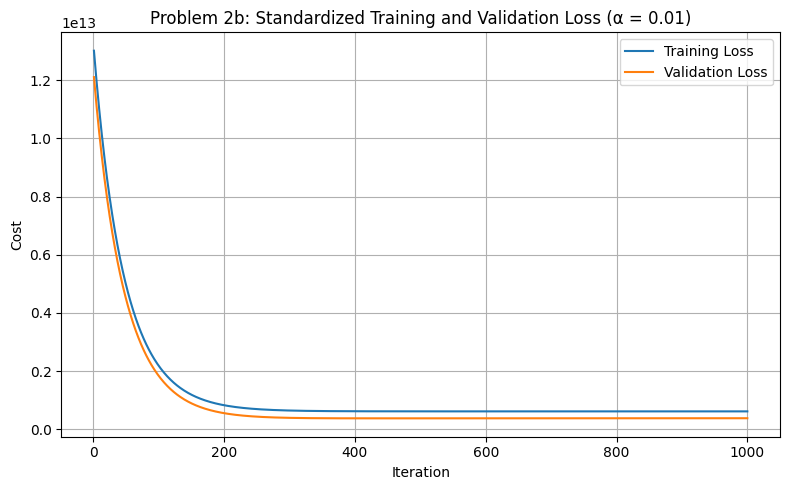

In [ ]:
plot_loss(
    results_1b_standardized,
    best_lr_1b_standardized,
    (
        'Problem 2b: Standardized Training and Validation Loss '
        f'(α = {best_lr_1b_standardized})'
    )
)

### Normalized Training and Validation Loss

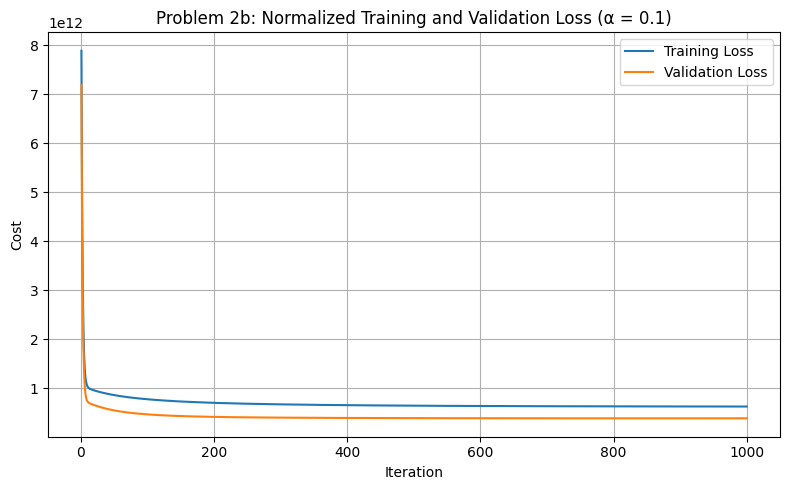

In [ ]:
plot_loss(
    results_1b_normalized,
    best_lr_1b_normalized,
    (
        'Problem 2b: Normalized Training and Validation Loss '
        f'(α = {best_lr_1b_normalized})'
    )
)

### Comparison with Problem 1b



In [ ]:
baseline_lr_1b = 0.01

comparison_2b_df = pd.DataFrame([
    {
        'Model': 'Problem 1b - Unscaled',
        'Learning Rate': baseline_lr_1b,
        'Iterations Completed':
            len(
                results_1b[
                    baseline_lr_1b
                ]['train_cost']
            ),
        'Final Training Cost':
            results_1b[
                baseline_lr_1b
            ]['train_cost'][-1],
        'Final Validation Cost':
            results_1b[
                baseline_lr_1b
            ]['test_cost'][-1]
    },
    {
        'Model': 'Problem 2b - Standardized',
        'Learning Rate': best_lr_1b_standardized,
        'Iterations Completed':
            len(
                results_1b_standardized[
                    best_lr_1b_standardized
                ]['train_cost']
            ),
        'Final Training Cost':
            results_1b_standardized[
                best_lr_1b_standardized
            ]['train_cost'][-1],
        'Final Validation Cost':
            results_1b_standardized[
                best_lr_1b_standardized
            ]['test_cost'][-1]
    },
    {
        'Model': 'Problem 2b - Normalized',
        'Learning Rate': best_lr_1b_normalized,
        'Iterations Completed':
            len(
                results_1b_normalized[
                    best_lr_1b_normalized
                ]['train_cost']
            ),
        'Final Training Cost':
            results_1b_normalized[
                best_lr_1b_normalized
            ]['train_cost'][-1],
        'Final Validation Cost':
            results_1b_normalized[
                best_lr_1b_normalized
            ]['test_cost'][-1]
    }
])

comparison_2b_df

,Model,Learning Rate,Iterations Completed,Final Training Cost,Final Validation Cost
0,Problem 1b - Unscaled,0.01,27,inf,inf
1,Problem 2b - Standardized,0.01,1000,6.195294e+11,3.843404e+11
2,Problem 2b - Normalized,0.10,1000,6.224365e+11,3.814117e+11


### Best Scaling Approach


In [ ]:
standardized_1b_train_loss = results_1b_standardized[
    best_lr_1b_standardized
]['train_cost'][-1]

standardized_1b_validation_loss = results_1b_standardized[
    best_lr_1b_standardized
]['test_cost'][-1]

normalized_1b_train_loss = results_1b_normalized[
    best_lr_1b_normalized
]['train_cost'][-1]

normalized_1b_validation_loss = results_1b_normalized[
    best_lr_1b_normalized
]['test_cost'][-1]

if standardized_1b_train_loss < normalized_1b_train_loss:
    best_training_scaling_1b = 'Standardization'
else:
    best_training_scaling_1b = 'Normalization'

if (
    standardized_1b_validation_loss
    < normalized_1b_validation_loss
):
    best_validation_scaling_1b = 'Standardization'
else:
    best_validation_scaling_1b = 'Normalization'

print(
    "Lowest final training loss:",
    best_training_scaling_1b
)

print(
    "Lowest final validation loss:",
    best_validation_scaling_1b
)

Lowest final training loss: Standardization
Lowest final validation loss: Normalization


### Results and Discussion

Results show how the additional housing characteristics from Problem 1b act when the input variables are placed on more comparable scales.

## Problem 3a

###Select Best Scaling Approach

In [ ]:
if best_validation_scaling == 'Standardization':
    X_train_3a = X_train_standardized_bias
    X_test_3a = X_test_standardized_bias

    results_2a_best = results_standardized
    best_lr_2a = best_lr_standardized

else:
    X_train_3a = X_train_normalized_bias
    X_test_3a = X_test_normalized_bias

    results_2a_best = results_normalized
    best_lr_2a = best_lr_normalized

print("Scaling method:", best_validation_scaling)

Scaling method: Normalization


### Regularized Training

In [ ]:
lambda_reg = 0.1

results_3a = {}

for lr in learning_rates:
    theta, train_cost_history, test_cost_history = gradient_descent(
        X_train_3a,
        Y_train,
        X_test_3a,
        Y_test,
        lr,
        iterations,
        lambda_reg
    )

    results_3a[lr] = {
        'theta': theta,
        'train_cost': train_cost_history,
        'test_cost': test_cost_history
    }

### Learning Rate Results

In [ ]:
comparison_3a_df = create_results_table(
    results_3a,
    learning_rates
)

comparison_3a_df

,Learning Rate,Iterations Completed,Final Training Cost,Final Validation Cost
0,0.01,1000,1.011253e+12,7.048580e+11
1,0.03,1000,8.819514e+11,6.120225e+11
2,0.05,1000,8.424431e+11,5.916627e+11
3,0.07,1000,8.269114e+11,5.851547e+11
4,0.10,1000,8.188576e+11,5.828506e+11


### Select Best Learning Rate

In [ ]:
valid_3a = comparison_3a_df[
    (comparison_3a_df['Iterations Completed'] == iterations)
    & np.isfinite(
        comparison_3a_df['Final Validation Cost']
    )
]

best_lr_3a = float(
    valid_3a.loc[
        valid_3a['Final Validation Cost'].idxmin(),
        'Learning Rate'
    ]
)

print("Best learning rate:", best_lr_3a)
print("Regularization parameter:", lambda_reg)

Best learning rate: 0.1
Regularization parameter: 0.1


### Training and Evaluation Loss


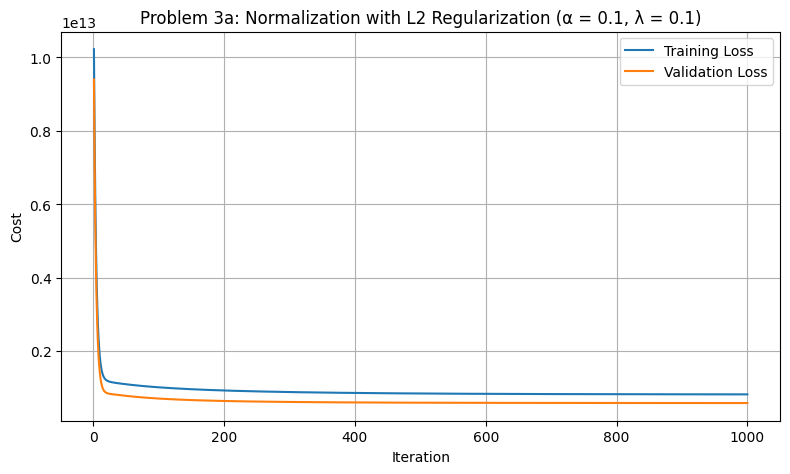

In [ ]:
plot_loss(
    results_3a,
    best_lr_3a,
    (
        f'Problem 3a: {best_validation_scaling} '
        f'with L2 Regularization '
        f'(α = {best_lr_3a}, λ = {lambda_reg})'
    )
)

### Comparison with Problem 2a

In [ ]:
comparison_3a_2a_df = pd.DataFrame([
    {
        'Model': 'Problem 2a',
        'Validation Loss':
            results_2a_best[
                best_lr_2a
            ]['test_cost'][-1]
    },
    {
        'Model': 'Problem 3a',
        'Validation Loss':
            results_3a[
                best_lr_3a
            ]['test_cost'][-1]
    }
])

comparison_3a_2a_df

,Model,Validation Loss
0,Problem 2a,5.829969e+11
1,Problem 3a,5.828506e+11


### Results and Discussion

3a repeated the best scaling approach from problem 2a while adding an L2 parameter penalty to the training.

The penalty is supposed to discourage the regression parameters from becoming unnecessarily large. The intercept parameter was excluded from the penalty as well.

The final validation loss can be compared directly with problem 2a to determine if the parameter improved performance or not.

## Problem 3b

### Select Best Scaling Approach

In [ ]:
if best_validation_scaling_1b == 'Standardization':
    X_train_3b = X_train_1b_standardized_bias
    X_test_3b = X_test_1b_standardized_bias

    results_2b_best = results_1b_standardized
    best_lr_2b = best_lr_1b_standardized

else:
    X_train_3b = X_train_1b_normalized_bias
    X_test_3b = X_test_1b_normalized_bias

    results_2b_best = results_1b_normalized
    best_lr_2b = best_lr_1b_normalized

print("Scaling method:", best_validation_scaling_1b)

Scaling method: Normalization


### Regularized Training

In [ ]:
results_3b = {}

for lr in learning_rates:
    theta, train_cost_history, test_cost_history = gradient_descent(
        X_train_3b,
        Y_train_1b,
        X_test_3b,
        Y_test_1b,
        lr,
        iterations,
        lambda_reg
    )

    results_3b[lr] = {
        'theta': theta,
        'train_cost': train_cost_history,
        'test_cost': test_cost_history
    }

### Learning Rate Results

In [ ]:
comparison_3b_df = create_results_table(
    results_3b,
    learning_rates
)

comparison_3b_df

,Learning Rate,Iterations Completed,Final Training Cost,Final Validation Cost
0,0.01,1000,7.724523e+11,4.626392e+11
1,0.03,1000,6.689076e+11,3.956655e+11
2,0.05,1000,6.421968e+11,3.851171e+11
3,0.07,1000,6.314785e+11,3.817885e+11
4,0.10,1000,6.255255e+11,3.811088e+11


### Select Best Learning Rate

In [ ]:
valid_3b = comparison_3b_df[
    (comparison_3b_df['Iterations Completed'] == iterations)
    & np.isfinite(comparison_3b_df['Final Validation Cost'])
]

best_lr_3b = float(
    valid_3b.loc[
        valid_3b['Final Validation Cost'].idxmin(),
        'Learning Rate'
    ]
)

print("Best learning rate:", best_lr_3b)
print("Regularization parameter:", lambda_reg)

Best learning rate: 0.1
Regularization parameter: 0.1


### Training and Evaluation Loss

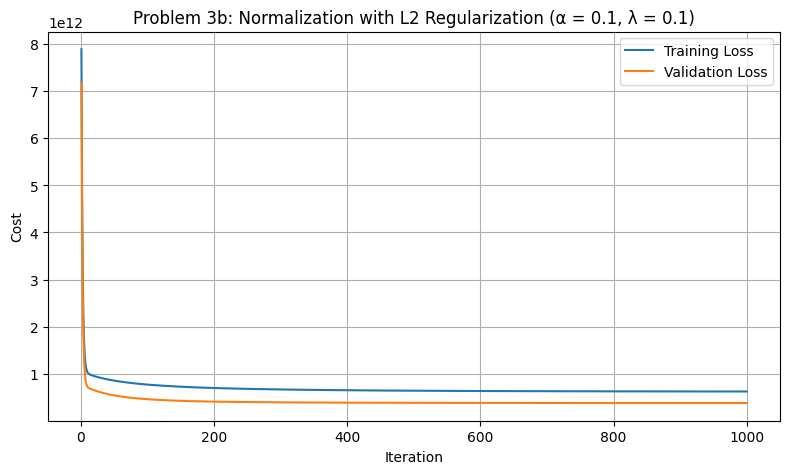

In [ ]:
plot_loss(
    results_3b,
    best_lr_3b,
    (
        f'Problem 3b: {best_validation_scaling_1b} '
        f'with L2 Regularization '
        f'(α = {best_lr_3b}, λ = {lambda_reg})'
    )
)

### Comparison with Problem 2b

In [ ]:
comparison_3b_2b_df = pd.DataFrame([
    {
        'Model': 'Problem 2b',
        'Validation Loss':
            results_2b_best[best_lr_2b]['test_cost'][-1]
    },
    {
        'Model': 'Problem 3b',
        'Validation Loss':
            results_3b[best_lr_3b]['test_cost'][-1]
    }
])

comparison_3b_2b_df

,Model,Validation Loss
0,Problem 2b,3.814117e+11
1,Problem 3b,3.811088e+11


### Results and Discussion

Problem 3b is the same as 2b and uses its best-performing input scaling approach with the L2 parameter penalty.

The penalty should discourage large regression parameters, with exception to the intercept parameter. The penalty was added in the training loss and gradient calculation, while the evaluation loss stayed the same.
